In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# Create a 20x20 grid of zeros
image = np.zeros((20,20))
# Change rows 3 - 6, and columns 3 - 6 to 255
image[3:7,1:7] = 255

cy, cx = 10, 10  # Center of the circle
radius = 4
for y in range(20):       # Loop over rows
    for x in range(20):   # Loop over columns
        # Check the Pythagorean distance
        if (y - cy)**2 + (x - cx)**2 <= radius**2:
            image[y, x] = 255

for y in range(1,20):
    for x in range(2,20):
        if y <= x - 10:
            image[y, x] = 128  


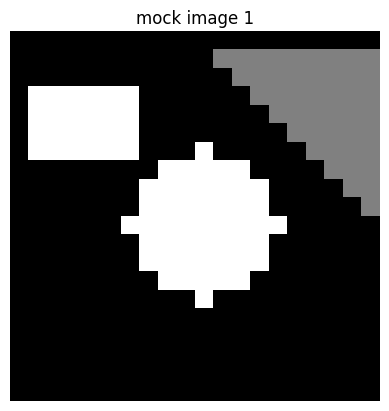

In [25]:
plt.imshow(image, cmap='gray')
plt.title('mock image 1')
plt.axis('off')
plt.show() 

In [35]:
basic_kernel=np.array(
            [[-1, 0, 1],
            [-1, 0, 1],
            [-1, 0, 1]])

basic_horizontal_kernel=np.array(
            [[-1, -1, -1],
            [0, 0, 0],
            [1, 1, 1]])

sobel_vertical_kernel=np.array(
            [[-1, 0, 1],
            [-2, 0, 2],
            [-1, 0, 1]])

sobel_horizontal_kernel=np.array(
            [[-1, -2, -1],
            [0, 0, 0],
            [1, 2, 1]])

Laplacian_4_kernel=np.array(
             [[ 0, -1,  0],
             [-1,  4, -1],
             [ 0, -1,  0]])

Laplacian_8_kernel=np.array(
             [[-1, -1, -1],
            [-1,  8, -1],
            [-1, -1, -1]])



In [36]:
def apply_filter(img, kernel):

    # 1. Initialize an empty output array (filled with zeros/black pixels) 
    #    that exactly matches the shape and data type of the input image.
    
    filtered_image = np.zeros_like(img)
    
    padded_img = np.pad(img, pad_width=1 )

    # 2. Slide a 3x3 window across the image. 
    #    Because we added a 1-pixel border to padded_img, every pixel from the original image has shifted over by 1 in padded_img.
    #    Pixel (0, 0) in our original img is now sitting at (1, 1) in your padded_img.
    #    So, if we want to grab the 3x3 patch around pixel (i, j) of the original image, we actually need to look at (i+1, j+1) in the padded_img

    #    image.shape[0] grabs the first number, which is the height (the total number of rows).
    #    image.shape[1] grabs the second number, which is the width (the total number of columns).

    for i in range(0, img.shape[0] ):
        for j in range(0, img.shape[1] ):
            
            # 3. the 3x3 local region centered at pixel (i, j)
            patch = padded_img[ i:i+3 , j:j+3]

            # 4. element-wise multiplication followed by a sum
            # 5. Store the newly computed value in the output image
            filtered_image[i, j] = np.sum(patch * kernel)
            
   
    return filtered_image


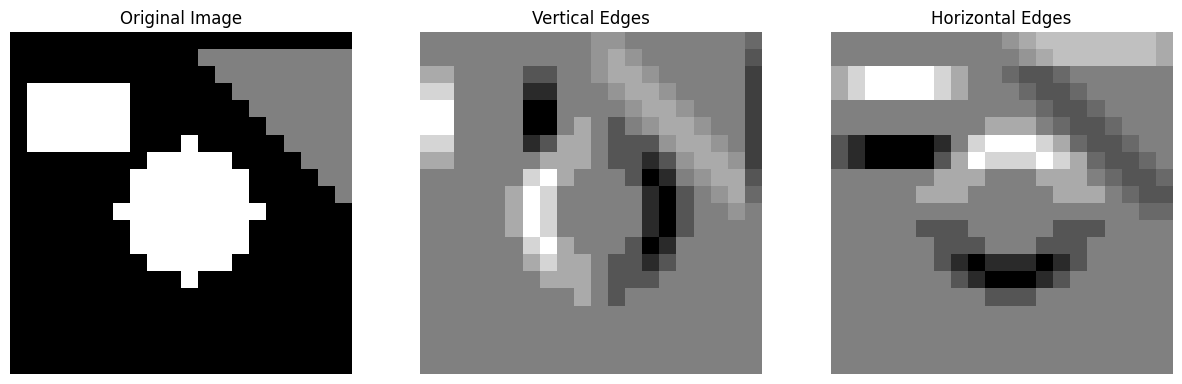

In [37]:
# Create a figure (the entire window) and an array of 'axes' (individual plots).
# 1 row, 3 columns means we want 3 plots side-by-side.
# figsize=(15, 5) sets the width to 15 inches and height to 5 inches.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- FIRST PLOT: The Original Image ---
# axes[0] targets the first plot (far left).
# cmap='gray' to draw in black and white.

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Apply and plot vertical
vert_img = apply_filter(image, basic_kernel)

axes[1].imshow(vert_img, cmap='gray')
axes[1].set_title('Vertical Edges')
axes[1].axis('off')

# Apply and plot horizontal
horiz_img = apply_filter(image, basic_horizontal_kernel)

axes[2].imshow(horiz_img, cmap='gray')
axes[2].set_title('Horizontal Edges')
axes[2].axis('off')

plt.show()


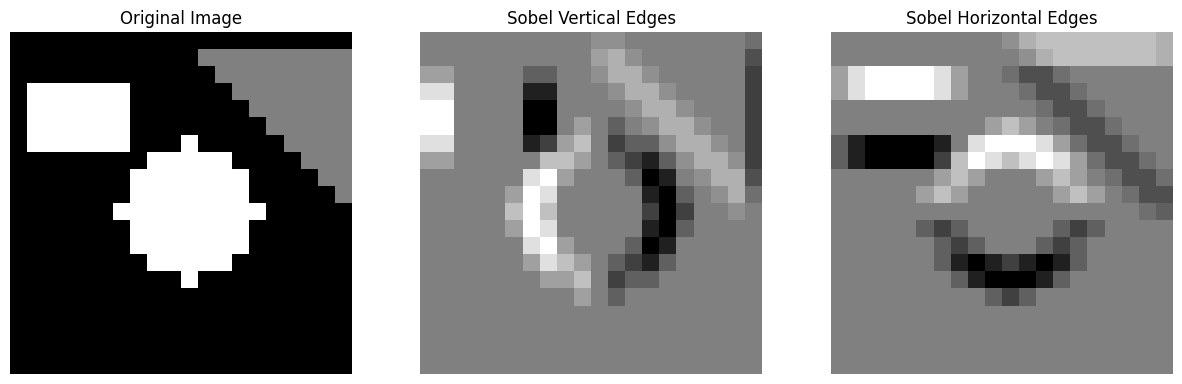

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Apply and plot sobel vertical
vert_img = apply_filter(image, sobel_vertical_kernel)

axes[1].imshow(vert_img, cmap='gray')
axes[1].set_title('Sobel Vertical Edges')
axes[1].axis('off')

# Apply and plot sobel horizontal
horiz_img = apply_filter(image, sobel_horizontal_kernel)

axes[2].imshow(horiz_img, cmap='gray')
axes[2].set_title('Sobel Horizontal Edges')
axes[2].axis('off')

plt.show()


(np.float64(-0.5), np.float64(19.5), np.float64(19.5), np.float64(-0.5))

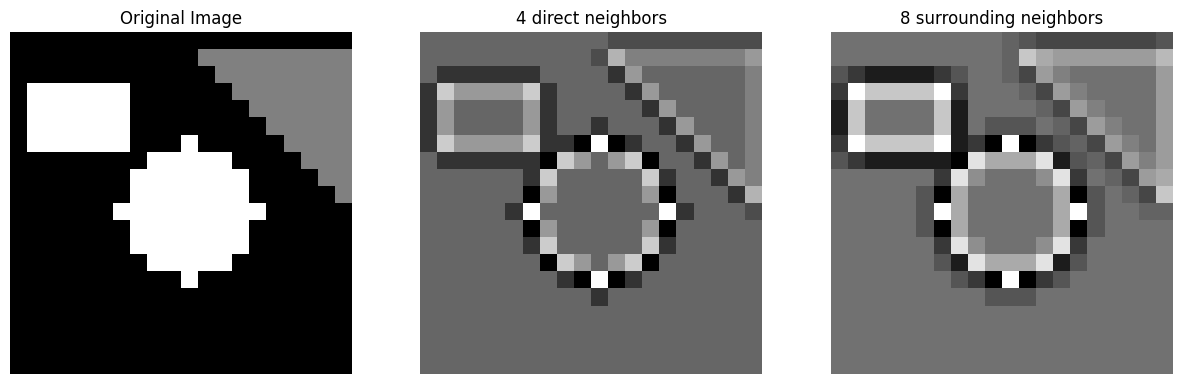

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Apply and plot 4-way Laplacian
lap_4_img = apply_filter(image, Laplacian_4_kernel)

axes[1].imshow(lap_4_img, cmap='gray')
axes[1].set_title('4 direct neighbors')
axes[1].axis('off')

# Apply and plot 8-way Laplacian
lap_8_img = apply_filter(image, Laplacian_8_kernel)

axes[2].imshow(lap_8_img, cmap='gray')
axes[2].set_title('8 surrounding neighbors')
axes[2].axis('off')